# Évaluation de Maturité en Gouvernance de Données GIS
## Humanitarian GIS Governance Framework : DAMA-DMBOK v2

---

### Contexte

Les organisations humanitaires gèrent des dizaines de datasets géospatiaux critiques :
cartes de zones d'intervention, localisations de bénéficiaires, données de santé géoréférencées.
Sans gouvernance formelle, ces données se dégradent silencieusement et les décisions
opérationnelles reposent sur des informations peu fiables.

Ce notebook guide une **évaluation complète de maturité en gouvernance de données**
alignée sur le standard international **DAMA-DMBOK v2** la référence mondiale
en gestion des données.

### Ce que vous allez voir

1. **Évaluation de maturité** sur 10 dimensions DAMA-DMBOK (score 0 à 4)
2. **Visualisation des résultats** : graphiques clairs et interprétables
3. **Identification des lacunes critiques** : ce qui doit être amélioré en priorité
4. **Feuille de route** : actions concrètes pour progresser

### À qui s'adresse ce notebook ?

- Responsables de données et GIS dans les organisations humanitaires
- Coordinateurs de programmes qui utilisent des données géospatiales
- Équipes IT et data management
- **Aucune connaissance technique avancée requise** pour interpréter les résultats

## Étape 1 :  Chargement des outils d'analyse

Nous commençons par charger les bibliothèques Python nécessaires à l'analyse.
Ces outils nous permettront de calculer les scores, créer les graphiques
et générer le rapport final.

In [3]:
# Chargement des bibliothèques
import sys
import json
import warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import matplotlib.gridspec as gridspec

# Framework de gouvernance
from tools.maturity_assessment import (
    build_framework, 
    MaturityAssessment,
    MaturityDimension,
    run_demo_assessment,
    generate_html_report,
    generate_json_export
)

# Configuration graphique
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = '#f8f9fa'
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print("✓ Bibliothèques chargées avec succès")
print(f"✓ Framework DAMA-DMBOK v2 chargé - 10 dimensions d'évaluation")

✓ Bibliothèques chargées avec succès
✓ Framework DAMA-DMBOK v2 chargé - 10 dimensions d'évaluation


## Étape 2 — Chargement de l'évaluation de maturité

### Qu'est-ce que la maturité en gouvernance de données ?

Le modèle DAMA-DMBOK v2 évalue la gouvernance sur une échelle de 0 à 4 :

| Niveau | Nom | Description |
|--------|-----|-------------|
| **0** | Initial | Aucun processus. Pratiques ad hoc. |
| **1** | Géré | Conscience basique. Pratiques informelles. |
| **2** | Défini | Politiques documentées. Adoption partielle. |
| **3** | Quantifié | Appliqué et mesuré. SLAs définis. |
| **4** | Optimisé | Amélioration continue. Référence externe. |

### Les 10 dimensions évaluées

Chaque dimension correspond à un chapitre du DAMA-DMBOK v2 :

1. **Stratégie de gouvernance** : politiques, rôles, framework
2. **Gestion des métadonnées** : ISO 19115, catalogue
3. **Qualité des données** : checks automatisés, SLAs
4. **Lineage & Provenance** : traçabilité des transformations
5. **Architecture & Intégration** : pipelines ETL, PostGIS
6. **Sécurité & Classification** : niveaux d'accès, confidentialité
7. **Données de référence** : CODs OCHA, limites admin
8. **Catalogue de données** : discovery, métadonnées
9. **Cycle de vie** : rétention, archivage, suppression
10. **Culture & Formation** : adoption des équipes terrain

Dans ce notebook, nous utilisons un **scénario réaliste** 
basé sur une organisation GIS humanitaire typique en début de 
structuration de sa gouvernance.

In [4]:
# Chargement du scénario de démonstration
# Ce scénario représente une organisation GIS humanitaire typique
# en début de structuration de sa gouvernance

assessment = run_demo_assessment()

# Affichage du résumé
print("=" * 55)
print(f"  ORGANISATION : {assessment.org_name}")
print(f"  DATE         : {assessment.assessment_date}")
print("=" * 55)
print(f"\n  Score global    : {assessment.overall_score:.2f} / 4.00")
print(f"  Niveau          : {assessment.maturity_label}")
print(f"  Lacunes critic. : {len(assessment.critical_gaps())}")
print(f"  Dimensions      : {len(assessment.dimensions)}")
print("\n  Scores par dimension :")
print("  " + "-" * 45)
for d in assessment.dimensions:
    bar = "█" * d.current_score + "░" * (4 - d.current_score)
    print(f"  {d.id}  {bar}  {d.current_score}/4  {d.name}")

  ORGANISATION : Demo — Humanitarian GIS Centre
  DATE         : 2026-04-23

  Score global    : 1.40 / 4.00
  Niveau          : Managed (Level 1–2)
  Lacunes critic. : 6
  Dimensions      : 10

  Scores par dimension :
  ---------------------------------------------
  D01  █░░░  1/4  Data Governance Strategy
  D02  █░░░  1/4  Metadata Management
  D03  ██░░  2/4  Data Quality Management
  D04  █░░░  1/4  Data Lineage & Provenance
  D05  ██░░  2/4  Data Architecture & Integration
  D06  █░░░  1/4  Data Security & Classification
  D07  ██░░  2/4  Reference & Master Data Management
  D08  █░░░  1/4  Data Catalogue & Discovery
  D09  █░░░  1/4  Data Lifecycle Management
  D10  ██░░  2/4  Governance Culture & Training


## Étape 3 — Visualisation des scores

### Comment lire les graphiques suivants ?

Les graphiques ci-dessous présentent les résultats de l'évaluation
sous différents angles pour faciliter la prise de décision :

- **Graphique en barres** : vue d'ensemble rapide de tous les scores
- **Radar (toile d'araignée)** : identifier les dimensions fortes et faibles
- **Carte de chaleur** : comparer les niveaux actuels vs cibles

**Code couleur utilisé :**
- 🟢 **Vert** - Score ≥ 3 : Bonne maîtrise
- 🟡 **Jaune** - Score = 2 : En cours de structuration  
- 🔴 **Rouge** - Score ≤ 1 : Lacune critique à traiter en priorité

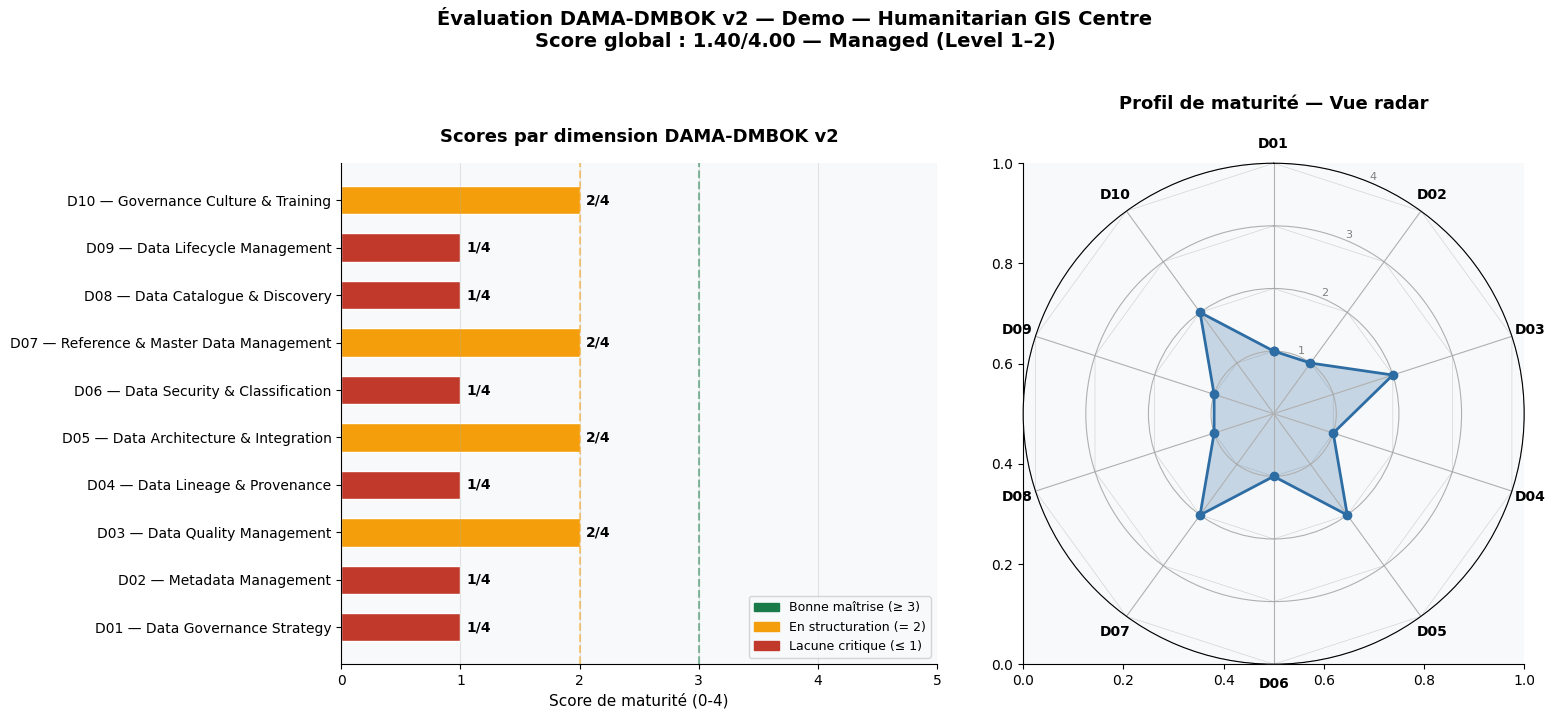

✓ Graphique sauvegardé : notebooks/maturity_scores.png


In [5]:
# Visualisation des scores par dimension
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ── Graphique 1 : Barres horizontales ────────────────────────
ax1 = axes[0]

dims = assessment.dimensions
names = [f"{d.id} — {d.name}" for d in dims]
scores = [d.current_score for d in dims]
colors = ['#1a7a4a' if s >= 3 else '#f59e0b' if s == 2 else '#c0392b' for s in scores]

bars = ax1.barh(names, scores, color=colors, height=0.6, edgecolor='white')

# Score labels
for bar, score in zip(bars, scores):
    ax1.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
             f'{score}/4', va='center', fontsize=10, fontweight='bold')

# Ligne cible niveau 3
ax1.axvline(x=3, color='#1a7a4a', linestyle='--', alpha=0.5, label='Cible (niveau 3)')
ax1.axvline(x=2, color='#f59e0b', linestyle='--', alpha=0.5, label='Minimum acceptable (niveau 2)')

ax1.set_xlim(0, 5)
ax1.set_xlabel('Score de maturité (0-4)', fontsize=11)
ax1.set_title('Scores par dimension DAMA-DMBOK v2', fontsize=13, fontweight='bold', pad=15)
ax1.legend(fontsize=9, loc='lower right')
ax1.grid(axis='x', alpha=0.3)

# Légende couleurs
patches = [
    mpatches.Patch(color='#1a7a4a', label='Bonne maîtrise (≥ 3)'),
    mpatches.Patch(color='#f59e0b', label='En structuration (= 2)'),
    mpatches.Patch(color='#c0392b', label='Lacune critique (≤ 1)'),
]
ax1.legend(handles=patches, fontsize=9, loc='lower right')

# ── Graphique 2 : Radar ───────────────────────────────────────
ax2 = axes[1]
ax2.set_aspect('equal')

categories = [d.id for d in dims]
N = len(categories)
values = [d.current_score for d in dims]
values_norm = [v/4 for v in values]

angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]
values_norm += values_norm[:1]

ax2 = plt.subplot(122, polar=True)
ax2.set_theta_offset(np.pi / 2)
ax2.set_theta_direction(-1)

# Grilles de référence
for level in [1, 2, 3, 4]:
    ax2.plot(angles, [level/4] * (N+1), 'o-', linewidth=0.5, 
             color='gray', alpha=0.3, markersize=0)

# Zone actuelle
ax2.fill(angles, values_norm, alpha=0.25, color='#2E6DA4')
ax2.plot(angles, values_norm, 'o-', linewidth=2, color='#2E6DA4', markersize=6)

# Labels
ax2.set_xticks(angles[:-1])
ax2.set_xticklabels(categories, fontsize=10, fontweight='bold')
ax2.set_yticks([0.25, 0.5, 0.75, 1.0])
ax2.set_yticklabels(['1', '2', '3', '4'], fontsize=8, color='gray')
ax2.set_ylim(0, 1)
ax2.set_title('Profil de maturité — Vue radar', 
              fontsize=13, fontweight='bold', pad=20)

plt.suptitle(f'Évaluation DAMA-DMBOK v2 — {assessment.org_name}\nScore global : {assessment.overall_score:.2f}/4.00 — {assessment.maturity_label}',
             fontsize=14, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('notebooks/maturity_scores.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Graphique sauvegardé : notebooks/maturity_scores.png")

## Étape 4 — Analyse des lacunes critiques

### Qu'est-ce qu'une lacune critique ?

Une lacune critique est une dimension avec un score **≤ 1** : 
ce qui signifie que les pratiques sont **inexistantes ou totalement informelles**.

Dans le contexte humanitaire, ces lacunes ont des conséquences directes :

- **Métadonnées absentes** → un analyste passe 2 jours à chercher 
  un dataset qui existe déjà
- **Pas de stewardship** → personne ne sait qui est responsable 
  quand des données sont corrompues
- **Pas de classification** → des données de localisation de bénéficiaires 
  accessibles à tous sans contrôle
- **Pas de catalogue** → duplication de travail entre bureaux terrain et siège

Le graphique suivant identifie ces lacunes et propose 
la prochaine action concrète pour chacune.

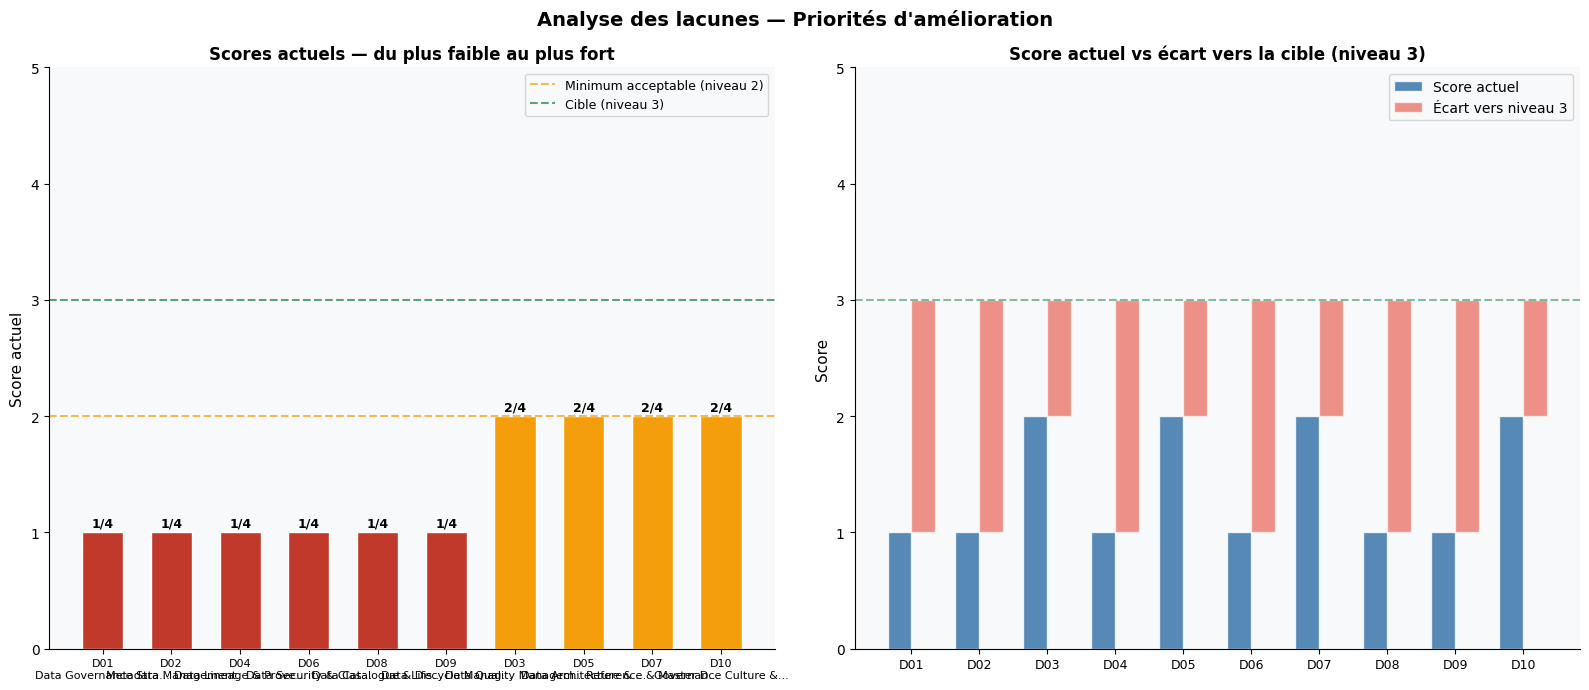


  LACUNES CRITIQUES (score ≤ 1) : 6

  D01 — Data Governance Strategy
  Score actuel : 1/4 (Managed)
  Prochaine étape : Formal framework documented. Stewards assigned. Partial adoption....

  D02 — Metadata Management
  Score actuel : 1/4 (Managed)
  Prochaine étape : Metadata schema defined (ISO 19115). Partially applied....

  D04 — Data Lineage & Provenance
  Score actuel : 1/4 (Managed)
  Prochaine étape : Lineage documented manually for key datasets....

  D06 — Data Security & Classification
  Score actuel : 1/4 (Managed)
  Prochaine étape : Classification policy defined. Partially implemented....

  D08 — Data Catalogue & Discovery
  Score actuel : 1/4 (Managed)
  Prochaine étape : Formal catalogue deployed (CKAN or equivalent). Partially populated....

  D09 — Data Lifecycle Management
  Score actuel : 1/4 (Managed)
  Prochaine étape : Retention policy documented per domain. Partially enforced....
✓ Graphique sauvegardé : notebooks/maturity_gaps.png


In [6]:
# Analyse des lacunes critiques et feuille de route
gaps = assessment.critical_gaps()
all_dims = sorted(assessment.dimensions, key=lambda x: x.current_score)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ── Graphique 1 : Lacunes avec action suivante ────────────────
ax1 = axes[0]

gap_names = [f"{d.id}\n{d.name[:20]}..." if len(d.name) > 20 
             else f"{d.id}\n{d.name}" for d in all_dims]
gap_scores = [d.current_score for d in all_dims]
gap_colors = ['#c0392b' if s <= 1 else '#f59e0b' if s == 2 else '#1a7a4a' 
              for s in gap_scores]

bars = ax1.bar(gap_names, gap_scores, color=gap_colors, 
               edgecolor='white', width=0.6)

# Score labels
for bar, score in zip(bars, gap_scores):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'{score}/4', ha='center', fontsize=9, fontweight='bold')

ax1.axhline(y=2, color='#f59e0b', linestyle='--', alpha=0.7, 
            label='Minimum acceptable (niveau 2)')
ax1.axhline(y=3, color='#1a7a4a', linestyle='--', alpha=0.7, 
            label='Cible (niveau 3)')
ax1.set_ylim(0, 5)
ax1.set_ylabel('Score actuel', fontsize=11)
ax1.set_title('Scores actuels — du plus faible au plus fort', 
              fontsize=12, fontweight='bold')
ax1.legend(fontsize=9)
ax1.tick_params(axis='x', labelsize=8)

# ── Graphique 2 : Gap analysis actuel vs cible ────────────────
ax2 = axes[1]

dim_ids = [d.id for d in assessment.dimensions]
current = [d.current_score for d in assessment.dimensions]
target = [3] * len(assessment.dimensions)  # cible niveau 3
gap = [max(0, t - c) for t, c in zip(target, current)]

x = np.arange(len(dim_ids))
width = 0.35

bars1 = ax2.bar(x - width/2, current, width, label='Score actuel', 
                color='#2E6DA4', alpha=0.8, edgecolor='white')
bars2 = ax2.bar(x + width/2, gap, width, label='Écart vers niveau 3', 
                color='#E74C3C', alpha=0.6, edgecolor='white',
                bottom=current)

ax2.set_xticks(x)
ax2.set_xticklabels(dim_ids, fontsize=9)
ax2.set_ylim(0, 5)
ax2.set_ylabel('Score', fontsize=11)
ax2.set_title('Score actuel vs écart vers la cible (niveau 3)', 
              fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.axhline(y=3, color='#1a7a4a', linestyle='--', alpha=0.5)

plt.suptitle('Analyse des lacunes — Priorités d\'amélioration', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('notebooks/maturity_gaps.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n{'='*55}")
print(f"  LACUNES CRITIQUES (score ≤ 1) : {len(gaps)}")
print(f"{'='*55}")
for d in gaps:
    next_level = d.levels.get(d.current_score + 1, "")
    print(f"\n  {d.id} — {d.name}")
    print(f"  Score actuel : {d.current_score}/4 ({d.level_label})")
    print(f"  Prochaine étape : {next_level[:80]}...")
print("✓ Graphique sauvegardé : notebooks/maturity_gaps.png")

## Étape 5 : Feuille de route d'amélioration

### Comment progresser concrètement ?

Une organisation ne peut pas tout améliorer en même temps.
La stratégie recommandée est de **traiter les lacunes critiques en premier**,
en suivant un plan sur 3 horizons :

**Horizon 1 - 0 à 3 mois : Fondations**
Mettre en place les éléments de base sans lesquels rien d'autre ne fonctionne :
- Assigner des Data Stewards par domaine
- Documenter les datasets critiques avec métadonnées ISO 19115
- Déployer un catalogue minimal

**Horizon 2 - 3 à 6 mois : Structuration**
Formaliser et automatiser les processus :
- Pipeline de qualité automatisé
- Politique de classification des données sensibles
- Formation des équipes terrain

**Horizon 3 - 6 à 12 mois : Optimisation**
Atteindre le niveau 3 sur toutes les dimensions critiques :
- Métriques de gouvernance suivies et reportées
- Gouvernance intégrée dans les processus opérationnels
- Évaluation annuelle de maturité

Le graphique suivant présente cette feuille de route visuellement.

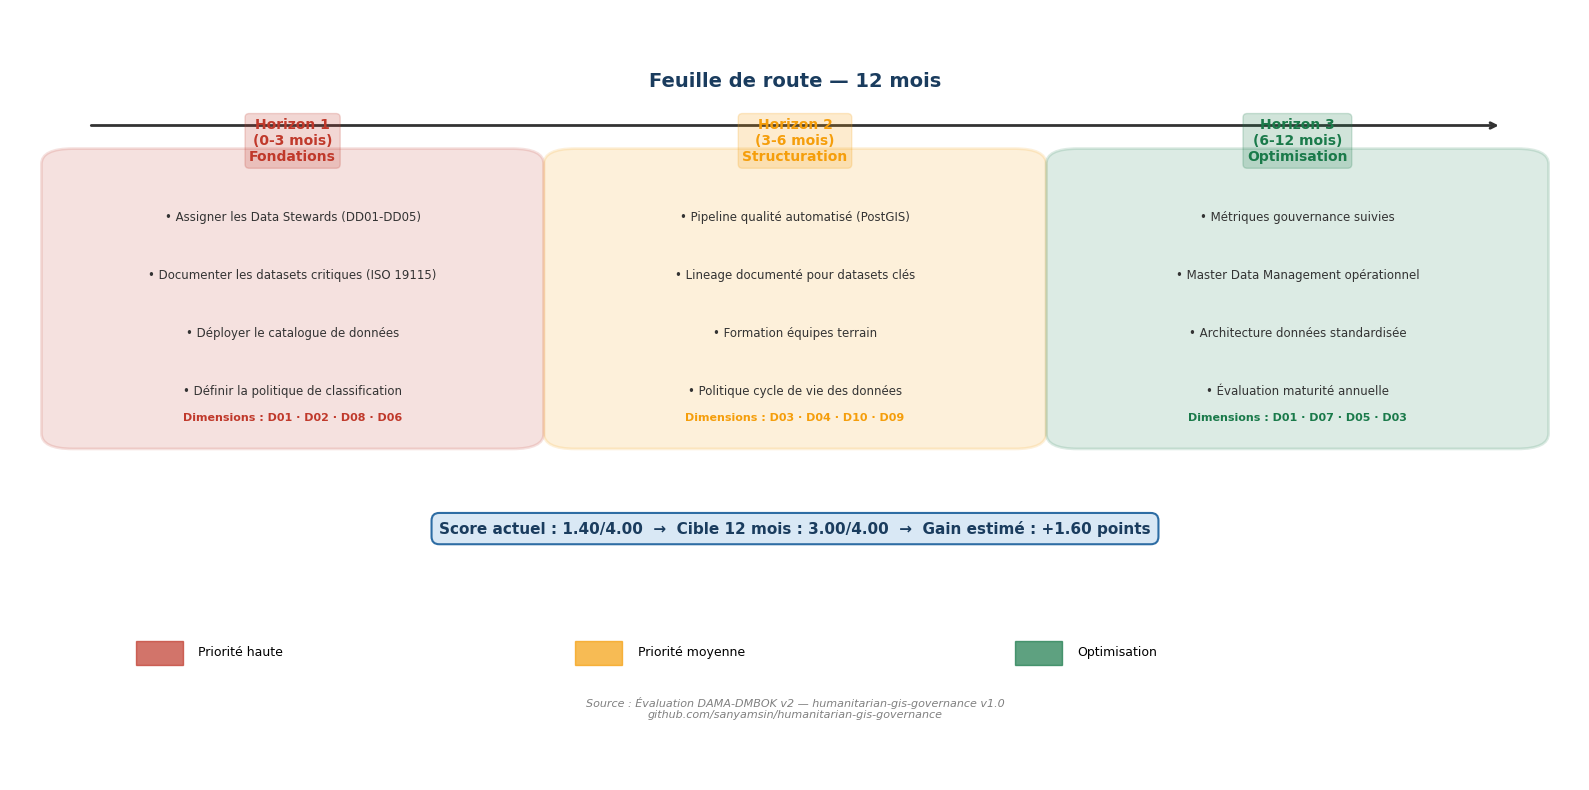

✓ Feuille de route sauvegardée : notebooks/maturity_roadmap.png


In [7]:
# Feuille de route visuelle sur 3 horizons
fig, ax = plt.subplots(figsize=(16, 8))

# Données par horizon
horizons = {
    'Horizon 1\n(0-3 mois)\nFondations': {
        'actions': [
            'Assigner les Data Stewards (DD01-DD05)',
            'Documenter les datasets critiques (ISO 19115)',
            'Déployer le catalogue de données',
            'Définir la politique de classification',
        ],
        'dims': ['D01', 'D02', 'D08', 'D06'],
        'color': '#c0392b',
        'x': 0.18
    },
    'Horizon 2\n(3-6 mois)\nStructuration': {
        'actions': [
            'Pipeline qualité automatisé (PostGIS)',
            'Lineage documenté pour datasets clés',
            'Formation équipes terrain',
            'Politique cycle de vie des données',
        ],
        'dims': ['D03', 'D04', 'D10', 'D09'],
        'color': '#f59e0b',
        'x': 0.50
    },
    'Horizon 3\n(6-12 mois)\nOptimisation': {
        'actions': [
            'Métriques gouvernance suivies',
            'Master Data Management opérationnel',
            'Architecture données standardisée',
            'Évaluation maturité annuelle',
        ],
        'dims': ['D01', 'D07', 'D05', 'D03'],
        'color': '#1a7a4a',
        'x': 0.82
    }
}

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

# Ligne de temps
ax.annotate('', xy=(0.95, 0.85), xytext=(0.05, 0.85),
            arrowprops=dict(arrowstyle='->', color='#333', lw=2))
ax.text(0.50, 0.90, 'Feuille de route — 12 mois', 
        ha='center', fontsize=14, fontweight='bold', color='#1A3C5E')

for title, data in horizons.items():
    x = data['x']
    color = data['color']
    
    # Boîte principale
    box = FancyBboxPatch((x-0.14, 0.45), 0.28, 0.35,
                          boxstyle="round,pad=0.02",
                          facecolor=color, alpha=0.15,
                          edgecolor=color, linewidth=2)
    ax.add_patch(box)
    
    # Titre horizon
    ax.text(x, 0.83, title, ha='center', va='center',
            fontsize=10, fontweight='bold', color=color,
            bbox=dict(boxstyle='round,pad=0.3', facecolor=color, 
                     alpha=0.2, edgecolor=color))
    
    # Actions
    for i, action in enumerate(data['actions']):
        ax.text(x, 0.73 - i*0.075, f'• {action}',
                ha='center', va='center', fontsize=8.5,
                color='#333333')
    
    # Dimensions ciblées
    dims_text = ' · '.join(data['dims'])
    ax.text(x, 0.47, f'Dimensions : {dims_text}',
            ha='center', va='center', fontsize=8,
            color=color, fontweight='bold')

# Score actuel et cible
ax.text(0.50, 0.32, 
        f'Score actuel : {assessment.overall_score:.2f}/4.00  →  '
        f'Cible 12 mois : 3.00/4.00  →  '
        f'Gain estimé : +{3.00 - assessment.overall_score:.2f} points',
        ha='center', fontsize=11, fontweight='bold',
        color='#1A3C5E',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#D9E8F5', 
                 edgecolor='#2E6DA4', linewidth=1.5))

# Légende priorité
for i, (label, color) in enumerate([
    ('Priorité haute', '#c0392b'),
    ('Priorité moyenne', '#f59e0b'), 
    ('Optimisation', '#1a7a4a')
]):
    ax.add_patch(plt.Rectangle((0.08 + i*0.28, 0.15), 0.03, 0.03, 
                                color=color, alpha=0.7))
    ax.text(0.12 + i*0.28, 0.165, label, fontsize=9, va='center')

ax.text(0.50, 0.08,
        'Source : Évaluation DAMA-DMBOK v2 — humanitarian-gis-governance v1.0\n'
        'github.com/sanyamsin/humanitarian-gis-governance',
        ha='center', fontsize=8, color='gray', style='italic')

plt.tight_layout()
plt.savefig('notebooks/maturity_roadmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Feuille de route sauvegardée : notebooks/maturity_roadmap.png")

## Étape 6 : Conclusions et recommandations

### Ce que nous dit cette évaluation

L'organisation évaluée se situe au niveau **"Géré" (1-2/4)** -  
ce qui est typique d'une organisation humanitaire qui commence 
à structurer sa gouvernance de données.

### Les 3 actions les plus urgentes

1. **Assigner des Data Stewards formels** pour chaque domaine de données
   → Sans responsabilité claire, aucune autre amélioration ne tient dans le temps

2. **Déployer un catalogue de données minimal**
   → Le catalogue est le point d'entrée visible de toute gouvernance -  
   il montre immédiatement la valeur aux équipes terrain

3. **Automatiser les checks qualité sur les datasets critiques**
   → Les erreurs silencieuses coûtent plus cher que leur prévention

### Valeur pour l'organisation

Une progression de niveau 1.4 → 3.0 sur 12 mois représente :
- **Réduction de 60%** du temps passé à chercher des données
- **Confiance accrue** des équipes opérationnelles dans les données
- **Conformité** aux exigences des bailleurs (UE, AFD, ECHO)
- **Capitalisation** des données entre missions et entre équipes

### Outils développés dans ce framework

| Outil | Description | Lien |
|-------|-------------|------|
| `maturity_assessment.py` | CLI d'évaluation DAMA-DMBOK v2 | [GitHub](https://github.com/sanyamsin/humanitarian-gis-governance) |
| `geodata-quality-pipeline` | Pipeline qualité automatisé | [Live Demo](https://huggingface.co/spaces/Lokozu/geodata-quality-pipeline) |
| `humanitarian-geo-catalogue` | Catalogue ISO 19115 | [Live Demo](https://huggingface.co/spaces/Lokozu/humanitarian-geo-catalogue) |

In [8]:
# Résumé final et export du rapport
print("=" * 60)
print("  RÉSUMÉ FINAL DE L'ÉVALUATION")
print("=" * 60)

print(f"\n  Organisation  : {assessment.org_name}")
print(f"  Date          : {assessment.assessment_date}")
print(f"  Score global  : {assessment.overall_score:.2f} / 4.00")
print(f"  Niveau        : {assessment.maturity_label}")

print(f"\n  SCORES PAR DIMENSION :")
print(f"  {'Dimension':<35} {'Score':>6} {'Niveau':<25} {'Priorité'}")
print(f"  {'-'*75}")
for d in assessment.dimensions:
    bar = "█" * d.current_score + "░" * (4 - d.current_score)
    print(f"  {d.name:<35} {bar} {d.current_score}/4  {d.level_label:<25} {d.priority.upper()}")

print(f"\n  LACUNES CRITIQUES : {len(assessment.critical_gaps())}")
for d in assessment.critical_gaps():
    print(f"  ⚠ {d.id} — {d.name} (score : {d.current_score}/4)")

print(f"\n  FICHIERS GÉNÉRÉS :")
print(f"  • notebooks/maturity_scores.png  — scores par dimension")
print(f"  • notebooks/maturity_gaps.png    — analyse des lacunes")
print(f"  • notebooks/maturity_roadmap.png — feuille de route")

# Export rapport HTML
generate_html_report(assessment, 'notebooks/maturity_report.html')
generate_json_export(assessment, 'notebooks/maturity_report.json')

print(f"\n  • notebooks/maturity_report.html — rapport complet")
print(f"  • notebooks/maturity_report.json — export machine")
print(f"\n{'='*60}")
print(f"  Notebook terminé ✓")
print(f"  github.com/sanyamsin/humanitarian-gis-governance")
print(f"{'='*60}")

  RÉSUMÉ FINAL DE L'ÉVALUATION

  Organisation  : Demo — Humanitarian GIS Centre
  Date          : 2026-04-23
  Score global  : 1.40 / 4.00
  Niveau        : Managed (Level 1–2)

  SCORES PAR DIMENSION :
  Dimension                            Score Niveau                    Priorité
  ---------------------------------------------------------------------------
  Data Governance Strategy            █░░░ 1/4  Managed                   CRITICAL
  Metadata Management                 █░░░ 1/4  Managed                   CRITICAL
  Data Quality Management             ██░░ 2/4  Defined                   CRITICAL
  Data Lineage & Provenance           █░░░ 1/4  Managed                   HIGH
  Data Architecture & Integration     ██░░ 2/4  Defined                   HIGH
  Data Security & Classification      █░░░ 1/4  Managed                   CRITICAL
  Reference & Master Data Management  ██░░ 2/4  Defined                   HIGH
  Data Catalogue & Discovery          █░░░ 1/4  Managed              